<a href="https://colab.research.google.com/github/deboraluz/deboraluz/blob/main/Profissao_Cientista_de_Dados_M18_Pratique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [7]:
# A)
print("Tipos de dados:")
print(df.dtypes)

Tipos de dados:
Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object


In [6]:
# B)
print("\nDados faltantes:")
print(df.isnull().sum())


Dados faltantes:
Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64


# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [8]:
# A)
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


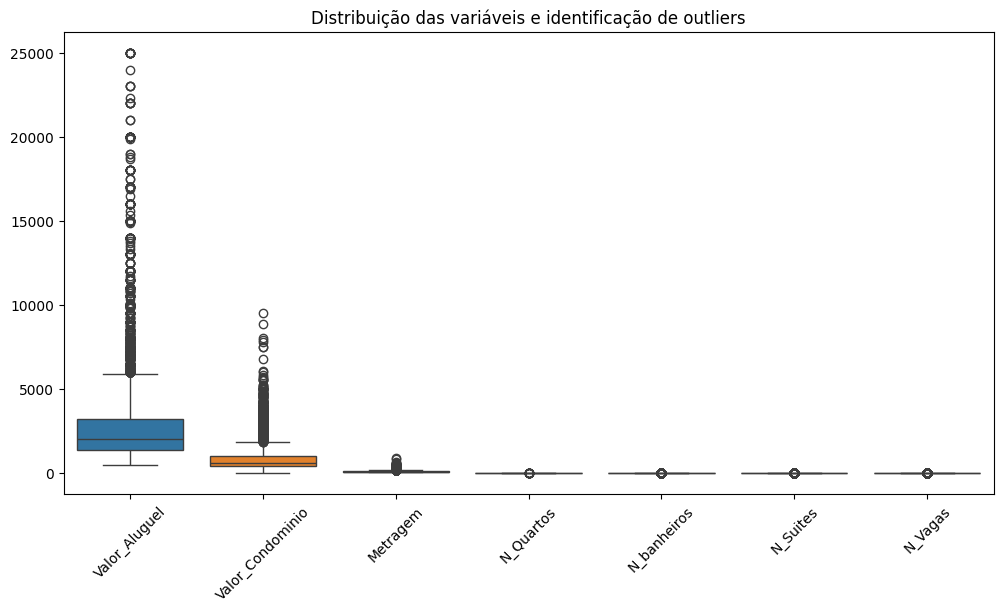

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title('Distribuição das variáveis e identificação de outliers')
plt.show()

In [10]:
# B)
Q1 = df['Valor_Aluguel'].quantile(0.25)
Q3 = df['Valor_Aluguel'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Q1: 1350.0
Q3: 3200.0
IQR: 1850.0
Limite inferior: -1425.0
Limite superior: 5975.0


A variável "Valor_Aluguel" apresenta valores extremos, identificados pelo método do IQR. Entretanto, por se tratar de valores de aluguel, esses registros podem representar imóveis de alto padrão e não necessariamente erros nos dados. Portanto, optei por não remover os outliers neste momento, evitando a perda de informações relevantes para o modelo de regressão.

In [14]:
# C)
correlacao = df.corr(numeric_only=True)['Valor_Aluguel'].sort_values(ascending=False)

print("Correlação com o Valor do Aluguel:")
print(correlacao)

Correlação com o Valor do Aluguel:
Valor_Aluguel       1.000000
Metragem            0.730591
Valor_Condominio    0.695302
N_Vagas             0.652858
N_Suites            0.614397
N_banheiros         0.603715
N_Quartos           0.413139
Name: Valor_Aluguel, dtype: float64


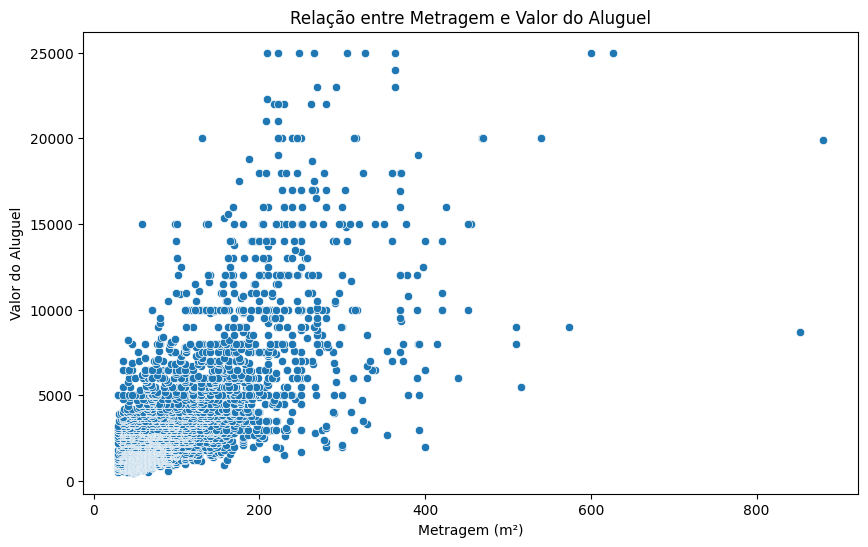

In [11]:
# C)
#Gráfico 1
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Metragem',
    y='Valor_Aluguel')

plt.title('Relação entre Metragem e Valor do Aluguel')
plt.xlabel('Metragem (m²)')
plt.ylabel('Valor do Aluguel')
plt.show()

A relação entre metragem e valor do aluguel é positiva: de maneira geral, imóveis maiores tendem a apresentar valores de aluguel maiores.
Isso é confirmado pela correlação de aproximadamente 0,73, que é uma relação positiva relativamente forte.
Também podemos perceber que existe bastante dispersão, principalmente nos imóveis de maior metragem.

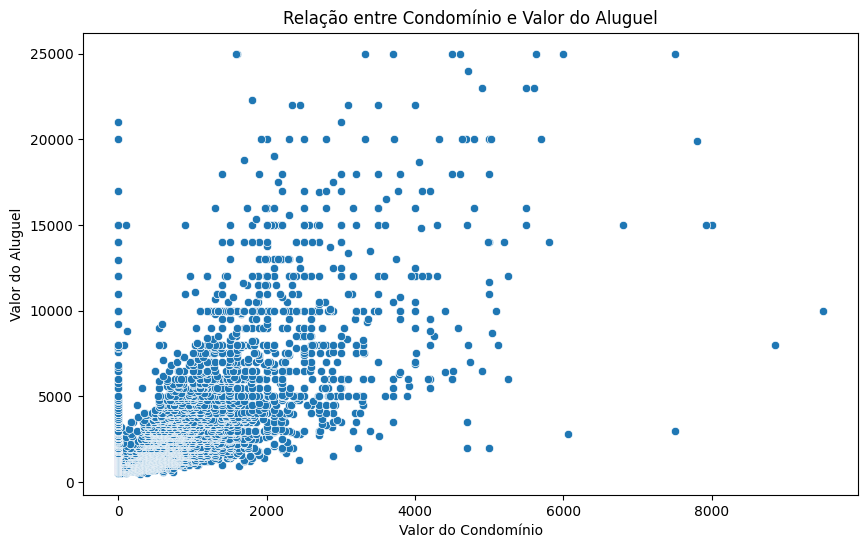

In [12]:
# C)
#Gráfico 2
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Valor_Condominio',
    y='Valor_Aluguel')

plt.title('Relação entre Condomínio e Valor do Aluguel')
plt.xlabel('Valor do Condomínio')
plt.ylabel('Valor do Aluguel')
plt.show()

Também existe uma relação positiva entre o valor do condomínio e o valor do aluguel.
A correlação encontrada é aproximadamente 0,70, indicando que imóveis com condomínios mais elevados tendem também a apresentar aluguéis maiores.
Isso pode estar relacionado ao padrão do imóvel, localização e estrutura oferecida pelo condomínio.

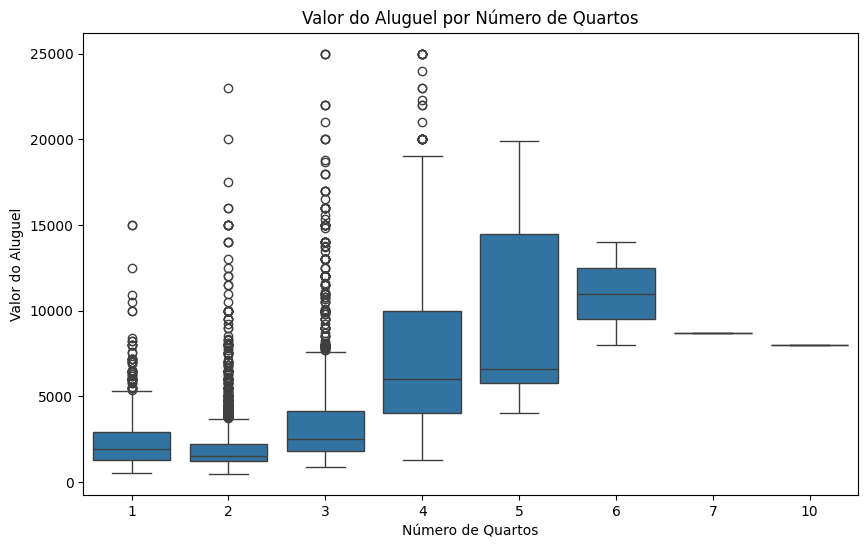

In [13]:
# C)
#Gráfico 3
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='N_Quartos', y='Valor_Aluguel')
plt.title('Valor do Aluguel por Número de Quartos')
plt.xlabel('Número de Quartos')
plt.ylabel('Valor do Aluguel')
plt.show()

O número de quartos também apresenta relação com o valor do aluguel.
Porém, a relação não é tão linear quanto a observada para a metragem e o condomínio.
Na base, por exemplo, os imóveis com 3 quartos apresentam aluguel médio superior aos imóveis com 1 ou 2 quartos. Os imóveis com 4 ou mais quartos também apresentam valores médios elevados, embora existam poucos registros nessas categorias.
A correlação entre "N_Quartos" e "Valor_Aluguel" é aproximadamente 0,41, portanto é uma relação positiva, mas mais moderada.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




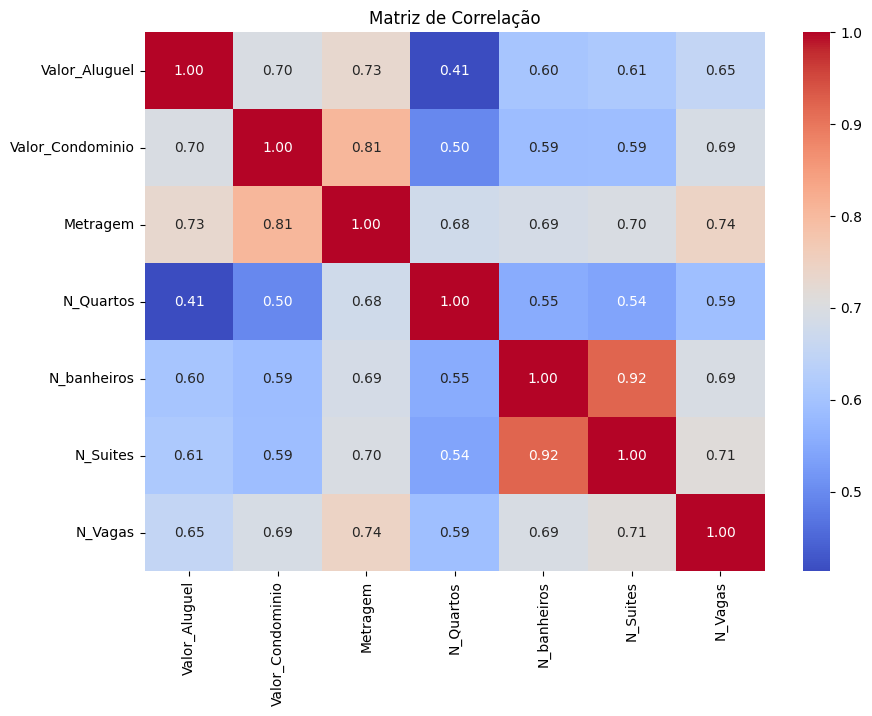

In [15]:
# A)
correlacao = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação')
plt.show()

A partir da matriz de correlação, podemos observar que as variáveis que apresentam maior correlação positiva com o "Valor_Aluguel" são "Metragem" e "Valor_Condominio". A "Metragem" apresenta a maior correlação, indicando que imóveis maiores tendem a apresentar valores de aluguel maiores. O "Valor_Condominio" também apresenta uma correlação positiva forte com o valor do aluguel.

As variáveis "N_Vagas", "N_Suites" e "N_banheiros" apresentam correlações positivas moderadas. Já "N_Quartos" apresenta uma correlação positiva mais fraca em comparação às demais.

Dessa forma, "Metragem" e "Valor_Condominio" parecem ser as variáveis mais relevantes para o modelo, considerando inicialmente a correlação com a variável que queremos prever "Valor_Aluguel)"


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [17]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [18]:
# B)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

In [19]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5762, 6)
X_test: (1441, 6)
y_train: (5762,)
y_test: (1441,)


# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [21]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [25]:
# a)
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X, y)

print("Intercepto:", modelo.intercept_)
print("Coeficiente da Metragem:", modelo.coef_[0])

Intercepto: -96.99896039931718
Coeficiente da Metragem: 34.47397089324867


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

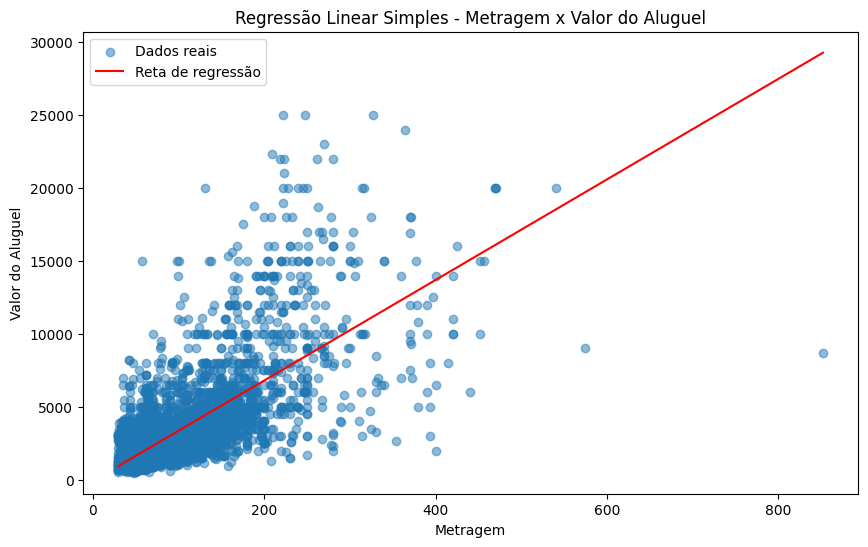

In [26]:

# B)
y_pred = modelo.predict(X)

# Ordenando os valores de Metragem para desenhar a reta
ordem = X['Metragem'].argsort()

X_ordenado = X.iloc[ordem]
y_pred_ordenado = y_pred[ordem]

# Gráfico
plt.figure(figsize=(10, 6))

plt.scatter(X, y, alpha=0.5, label='Dados reais')

plt.plot(
    X_ordenado,
    y_pred_ordenado,
    color='red',
    label='Reta de regressão'
)

plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Linear Simples - Metragem x Valor do Aluguel')
plt.legend()
plt.show()

Nossa equação seria:  
Valor do Aluguel previsto = 345,2109 + (0,8189 × Metragem)

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [31]:
# c)
from sklearn.metrics import r2_score

In [30]:
r2 = r2_score(y, y_pred)
print("R² do modelo de treinamento:", r2)

R² do modelo de treinamento: 0.521363231851778


O modelo apresentou um R² de aproximadamente 0,52, indicando que a variável Metragem explica cerca de 52,14% da variação do Valor_Aluguel nos dados de treinamento. Esse resultado pode ser considerado razoável, pois a metragem apresenta uma relação relevante com o valor do aluguel, porém ainda existe uma parcela significativa da variação que não é explicada pelo modelo. Isso indica que outras características dos imóveis podem contribuir para uma previsão mais precisa do valor do aluguel.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

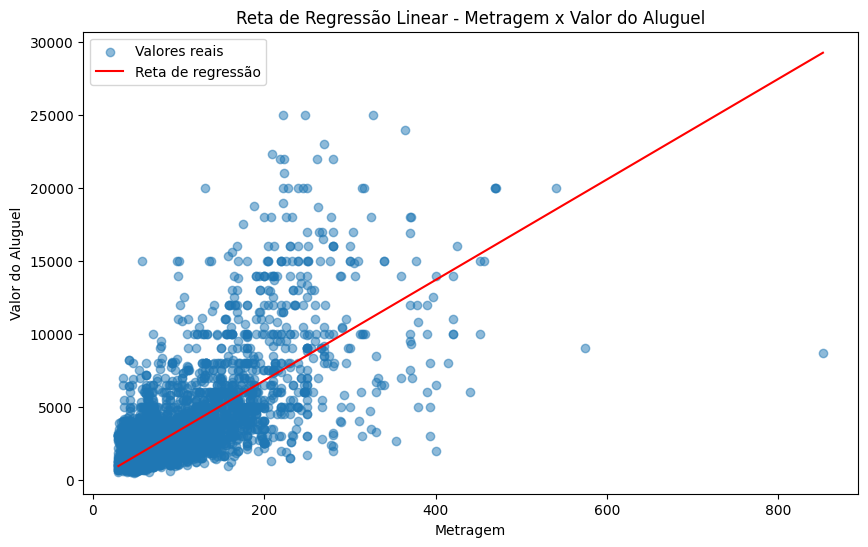

In [34]:
# D)
y_pred = modelo.predict(X)

# Organização dos dados para desenhar a reta corretamente
ordem = X['Metragem'].argsort()

X_ordenado = X.iloc[ordem]
y_pred_ordenado = y_pred[ordem]

# Gráfico da reta de regressão
plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    alpha=0.5,
    label='Valores reais')

plt.plot(
    X_ordenado,
    y_pred_ordenado,
    color='red',
    label='Reta de regressão')

plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Reta de Regressão Linear - Metragem x Valor do Aluguel')
plt.legend()
plt.show()

Observando o gráfico, percebe-se que existe uma tendência positiva entre a metragem dos imóveis e o valor do aluguel, representada pela inclinação positiva da reta de regressão. Entretanto, os pontos apresentam uma dispersão considerável em relação à reta, indicando que a metragem, apesar de possuir uma relação relevante com o valor do aluguel, não é suficiente para explicar toda a variação dos preços. Esse resultado está de acordo com o R² de aproximadamente 0,52, que indica que cerca de 52,14% da variação do valor do aluguel é explicada pela metragem. Portanto, o ajuste da reta pode ser considerado razoável, mas há espaço para melhorar o modelo utilizando outras características dos imóveis.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [36]:
# Separando apenas a variável Metragem dos dados de teste
X_test_metragem = X_test[['Metragem']]

y_test_metragem = y_test

# Fazendo previsões nos dados de teste
previsoes = modelo.predict(X_test_metragem)

# Calculando o R² nos dados de teste
r2 = modelo.score(X_test_metragem, y_test_metragem)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.5697993791211697


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

Escreva sua resposta aqui:
O modelo apresentou um R² de aproximadamente 0,52 no conjunto de treino, indicando que a variável "Metragem" consegue explicar cerca de 52,14% da variação do valor do aluguel. Já no conjunto de teste, o R² foi de aproximadamente 0,57, mostrando que o modelo conseguiu explicar cerca de 56,98% da variação dos valores de aluguel em dados que não foram utilizados durante o treinamento.

Os valores de R² são relativamente próximos, o que indica que o modelo manteve um desempenho semelhante ao ser aplicado aos dados de teste. Apesar disso, como aproximadamente 43% da variação do aluguel ainda não é explicada pelo modelo, acredito que utilizar apenas a "Metragem" não seja suficiente para realizar previsões muito precisas. A inclusão de outras características dos imóveis pode melhorar o desempenho do modelo.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [37]:
# Separando X e y

X = df.drop('Valor_Aluguel', axis=1)

y = df['Valor_Aluguel']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

In [43]:
X_treino_multipla = X_train
y_treino_multipla = y_train

X_teste_multipla = X_test
y_teste_multipla = y_test

In [46]:
print("X_train:", X_treino_multipla.shape)
print("X_test:", X_teste_multipla.shape)
print("y_train:", y_treino_multipla.shape)
print("y_test:", y_teste_multipla.shape)

X_train: (5762, 6)
X_test: (1441, 6)
y_train: (5762,)
y_test: (1441,)


B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [47]:
# Criando o modelo de regressão linear múltipla
modelo_multiplo = LinearRegression()

# Treinando o modelo somente com os dados de treino
modelo_multiplo.fit(X_train, y_train)

LinearRegression()

In [48]:
print("Intercepto:", modelo_multiplo.intercept_)

print("\nCoeficientes:")
for variavel, coeficiente in zip(X_train.columns, modelo_multiplo.coef_):
    print(variavel, ":", coeficiente)

Intercepto: 435.29273156066256

Coeficientes:
Valor_Condominio : 0.7840067829424151
Metragem : 20.681356888338154
N_Quartos : -649.1218865708462
N_banheiros : 223.7115348638589
N_Suites : 340.337884841421
N_Vagas : 501.24631768753693


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [49]:
r2_treino_multiplo = modelo_multiplo.score(X_train, y_train)

print("R² do modelo de regressão múltipla:", r2_treino_multiplo)

R² do modelo de regressão múltipla: 0.5958025784571297


D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [51]:
previsoes_multiplo = modelo_multiplo.predict(X_test)

r2_teste_multiplo = modelo_multiplo.score(X_test, y_test)

print("R² do modelo de regressão múltipla nos dados de teste:", r2_teste_multiplo)

R² do modelo de regressão múltipla nos dados de teste: 0.6400782589585374


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

Digite sua resposta aqui:
A regressão múltipla é melhor porque utiliza mais informações sobre cada imóvel, permitindo explicar uma parcela maior da variação do valor do aluguel: 64,01% no teste contra 56,98% da regressão simples.